In [1]:
import networkx as nx
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from pyvis.network import Network
import datetime as dt
from IPython.display import display, HTML
os.chdir('/users/sgdbareh/volatile/ECHR_Importance/Knowledge_Graph')


#### Load Data

In [2]:
# Load the outcome cases
outcome_cases = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Art_3_Data_Process/outcome_cases_for_network.pkl')
outcome_summaries = pd.read_pickle('/users/sgdbareh/volatile/ECHR_Importance/Summarize_Cases/Results/outcome_summaries.pkl')

assert len(outcome_cases) < len(outcome_summaries)

outcome_cases.columns

Index(['Facts', 'Word Count', 'The Law', 'date', 'File', 'appno',
       'doctypebranch', 'respondent', 'extractedappno', 'conclusion',
       'importance', 'kpthesaurus', 'doctype', 'article', 'languageisocode',
       'appnoparts', 'scl', 'docname', 'documentcollectionid', 'ecli',
       'sclappnos', 'appno_list', 'unique_app_no', 'citations',
       'new_list_length', 'citation_len'],
      dtype='object')

In [3]:
outcome_cases

,Facts,Word Count,The Law,date,File,appno,doctypebranch,respondent,extractedappno,conclusion,...,scl,docname,documentcollectionid,ecli,sclappnos,appno_list,unique_app_no,citations,new_list_length,citation_len
6622,2. The applicant was born in 1977 and lives in...,1962,ALLEGED VIOLATION OF ARTICLES 3 AND 8 OF THE C...,2024-07-18,001-235016,40861/22,CHAMBER,LVA,40861/22;41288/15;50231/13;07/18;12060/12;1923...,Preliminary objection dismissed (Art. 35) Admi...,...,"Association ACCEPT and Others v. Romania, no. ...",CASE OF HANOVS v. LATVIA,CASELAW;JUDGMENTS;CHAMBER;ENG,ECLI:CE:ECHR:2024:0718JUD004086122,19237/16;37882/13;73235/12;12060/12;71367/12;7...,[40861/22],40861/22,"[71367/12, 55974/16, 37882/13, 73204/13, 22597...",17,11
7131,1. The case concerns the applicant’s allegatio...,424,The applicant has been in detention since 15 O...,2024-07-11,001-234803,34590/06,COMMITTEE,UKR,34590/06;23380/09;30198/11;11006/06;39488/07;3...,Violation of Article 3 - Prohibition of tortur...,...,,CASE OF MATYUSHONOK v. UKRAINE,CASELAW;JUDGMENTS;COMMITTEE;ENG,ECLI:CE:ECHR:2024:0711JUD003459006,None,[34590/06],34590/06,"[38771/05, 1291/03, 7334/13, 39908/05, 36650/0...",24,7
7128,"1. The case concerns, under Article 3 of the C...",777,ALLEGED VIOLATION OF ARTICLE 3 OF THE CONVENTI...,2024-07-04,001-234584,15355/15,COMMITTEE,GEO,15355/15;14142/15;23380/09;31959/13;21571/05;5...,Violation of Article 3 - Prohibition of tortur...,...,,CASE OF MAMULASHVILI v. GEORGIA,CASELAW;JUDGMENTS;COMMITTEE;ENG,ECLI:CE:ECHR:2024:0704JUD001535515,None,[15355/15],15355/15,"[23380/09, 21571/05, 31959/13, 55506/08, 14142...",5,5
7129,1. The case mainly concerns the applicant’s co...,102,alleged violation of article 3 of the conventi...,2024-07-04,001-234585,54015/17,COMMITTEE,UKR,54015/17;77248/12;17116/04;44973/04;56668/12;2...,Violation of Article 3 - Prohibition of tortur...,...,,CASE OF ORLOV v. UKRAINE (No. 2),CASELAW;JUDGMENTS;COMMITTEE;ENG,ECLI:CE:ECHR:2024:0704JUD005401517,None,[54015/17],54015/17,"[23380/09, 77248/12, 38683/06, 56668/12, 41720...",13,12
7130,1. The case concerns the applicant’s continued...,1126,ALLEGED VIOLATION OF ARTICLE 3 OF THE CONVENTI...,2024-07-04,001-234587,29926/20,COMMITTEE,ITA,29926/20;36925/10;49268/10;19090/20;50494/12;5...,Violation of Article 3 - Prohibition of tortur...,...,,CASE OF A.Z. v. ITALY,CASELAW;JUDGMENTS;COMMITTEE;ENG,ECLI:CE:ECHR:2024:0704JUD002992620,None,[29926/20],29926/20,"[47152/06, 49268/10, 54547/16, 19090/20, 36925...",10,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4567,1. The case was referred to the Court by the a...,11060,I. ALLEGED VIOLATION OF ARTICLE 3 OF THE CONVE...,1996-11-28,001-58008,23366/94,CHAMBER,NLD,23366/94,Preliminary objection rejected (victim);No vio...,...,Moustaquim v. Belgium judgment of 18 February ...,CASE OF NSONA v. THE NETHERLANDS,CASELAW;JUDGMENTS;CHAMBER;ENG,ECLI:CE:ECHR:1996:1128JUD002336694,,[23366/94],23366/94,[],0,0
7138,1. The case was referred to the Court by the G...,30736,I. ALLEGED VIOLATION OF ARTICLE 3 OF THE CONVE...,1996-11-15,001-58004,22414/93,GRANDCHAMBER,GBR,22414/93;7317/75,Violation of Art. 3;Violation of Art. 5-4;Viol...,...,Ireland v. the United Kingdom judgment of 18 J...,CASE OF CHAHAL v. THE UNITED KINGDOM,CASELAW;JUDGMENTS;GRANDCHAMBER;ENG,ECLI:CE:ECHR:1996:1115JUD002241493,5029/71;7990/77;14038/88;22384/93,[22414/93],22414/93,[],5,0
4566,1. The case was referred to the Court by the E...,2207,THE GOVERNMENT'S PRELIMINARY OBJECTIONS24. The...,1996-08-07,001-58000,19092/91,CHAMBER,TUR,19092/91,Preliminary objection allowed (ratione tempori...,...,Loizidou v. Turkey (preliminary objections) ju...,CASE OF YAĞIZ v. TURKEY,CASELAW;JUDGMENTS;CHAMBER;ENG,ECLI:CE:ECHR:1996:0807JUD001909291,16419/90;16026/90,[19092/91],19092/91,[],2,0
4565,1. The case was referred to the Court by the E...,13526,I. ALLEGED VIOLATION OF ARTICLE 3 (art. 3) OF ...,1995-12-04,001-57964,18896/91,CHAMBER,AUT,18896/91,Violation of Art. 3;Non

In [25]:
outcome_summaries.rename(columns={'Filename':'File'}, inplace=True)

In [26]:
network_data = pd.merge(outcome_cases, outcome_summaries, on='File', how='inner')

#### Process for NetworkX

In [27]:
#don't filter because just because a node has no citations does not mean it was not cited
#network_data = network_data[network_data['citation_len'] > 0]

#len(network_data)

In [40]:
pd.set_option('display.max_columns', None)
network_data.head(1)

,Facts,Word Count,The Law,date,File,appno,doctypebranch,respondent,extractedappno,conclusion,importance,kpthesaurus,doctype,article,languageisocode,appnoparts,scl,docname,documentcollectionid,ecli,sclappnos,appno_list,unique_app_no,citations,new_list_length,citation_len,200 Word Summary,500 Word Summary
0,2. The applicant was born in 1977 and lives in...,1962,ALLEGED VIOLATION OF ARTICLES 3 AND 8 OF THE C...,2024-07-18,001-235016,40861/22,CHAMBER,LVA,40861/22;41288/15;50231/13;07/18;12060/12;1923...,Preliminary objection dismissed (Art. 35) Admi...,3,343;100;350;596;633;429;451;216;283;577;90;193...,HEJUD,14;14+3;3;14+8;8;8-1;41;35;35-1,ENG,40861;22,"Association ACCEPT and Others v. Romania, no. ...",CASE OF HANOVS v. LATVIA,CASELAW;JUDGMENTS;CHAMBER;ENG,ECLI:CE:ECHR:2024:0718JUD004086122,19237/16;37882/13;73235/12;12060/12;71367/12;7...,[40861/22],40861/22,"[71367/12, 55974/16, 37882/13, 73204/13, 22597...",17,11,"The applicant, born in 1977 and residing in Ri...","The applicant, born in 1977 and residing in Ri..."


In [41]:
G = nx.DiGraph()

#add the cases in as nodes
for i, row in network_data.iterrows():
    G.add_node(row['File'], label=row['docname'], outcome=row['conclusion'], importance=row['importance'], branch=row['doctypebranch'], date=row['date'].strftime('%Y-%m-%d'), respondent=row['respondent'], appno=row['unique_app_no'],ecli=row['ecli'],facts=row['Facts'],the_law=row['The Law'])

In [30]:
countries = network_data['respondent'].value_counts()

In [31]:
country_list = countries.index.tolist()
country_list = [x.split(';') for x in country_list]
country_list = [item for sublist in country_list for item in sublist]
country_list = list(set(country_list))
country_list

['SRB',
 'LIE',
 'NOR',
 'ALB',
 'SVK',
 'MDA',
 'ROU',
 'POL',
 'HUN',
 'ARM',
 'MNE',
 'ESP',
 'MKD',
 'GEO',
 'RUS',
 'CZE',
 'BEL',
 'IRL',
 'BIH',
 'LTU',
 'GBR',
 'AZE',
 'SMR',
 'CHE',
 'FRA',
 'TUR',
 'BGR',
 'GRC',
 'LVA',
 'PRT',
 'UKR',
 'HRV',
 'NLD',
 'FIN',
 'SWE',
 'MLT',
 'ITA',
 'AUT',
 'DEU',
 'ISL',
 'SVN',
 'EST',
 'DNK',
 'CYP']

In [32]:
#add country nodes
for country in country_list:
    G.add_node(country, type='country')

In [33]:
#add branch nodes
branches = network_data['doctypebranch'].value_counts()
branches = branches.index.tolist()
for branch in branches:
    G.add_node(branch, type='branch')

In [34]:
#add importance nodes
importances = network_data['importance'].value_counts() 
importances = importances.index.tolist()
importances = ['importance_'+str(x) for x in importances if x != '']

for importance in importances:
    G.add_node(importance, type='importance')

In [35]:
#add article nodes
keywords = network_data['kpthesaurus'].value_counts()
keywords = keywords.index.tolist()
keywords = [x.split(';') for x in keywords]
keywords = [item for sublist in keywords for item in sublist]
keywords = list(set(keywords))

with open('/users/sgdbareh/volatile/ECHR_Importance/Art_3_Data/key_labels.json', 'r') as f:
     key_labels = json.load(f)

#link the keywords to the labels for readability
for keyword in keywords:
    if keyword != '350':
         G.add_node(keyword, type='keyword', label=key_labels[keyword])


In [36]:
def search_nodes_by_attribute(graph, attribute, value):
    nodes_with_attribute = nx.get_node_attributes(graph, attribute)
    matching_nodes = [node for node, attr_value in nodes_with_attribute.items() if attr_value == value]
    return matching_nodes

# Example usage:
matching_nodes = search_nodes_by_attribute(G, 'appno', '40861/22')
print(matching_nodes)

['001-235016']


In [ ]:
# add the edges 
for i, row in network_data.iterrows():
    G.add_edge(row['File'], row['doctypebranch'],type='branch',timestamp=row['date'])
    G.add_edge(row['File'], 'importance_'+str(row['importance']),type='importance')

    #add the country edges
    countries = row['respondent'].split(';')
    for country in countries:
        G.add_edge(row['File'], country, type='country')

    #add the keyword edges
    keywords = row['kpthesaurus'].split(';')
    for keyword in keywords:
        if keyword in G.nodes():
            G.add_edge(row['File'], keyword, type='keyword')

    #add the citation edges
    citations = row['citations']
    for citation in citations:
        matching_file_no = search_nodes_by_attribute(G, 'appno', citation)
        if len(matching_file_no) > 1:
            raise ValueError('Multiple files with the same appno')
        elif len(matching_file_no) == 0:
            raise ValueError('No files with the appno')
        G.add_edge(row['File'], matching_file_no[0])



In [39]:
G.nodes['importance_2']

{'type': 'importance'}

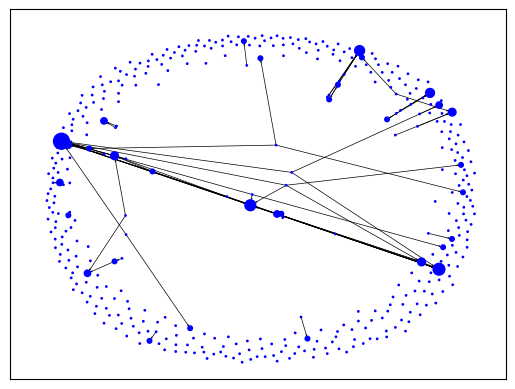

In [76]:
def create_subgraph_by_date(graph, start_date, end_date):
    #subgraph_nodes = [node for node, data in graph.nodes(data=True) if ('date' in data and start_date <= dt.datetime.strptime(data['date'], '%Y-%m-%d') <= end_date or 'date' not in data)]
    subgraph_nodes = [node for node, data in graph.nodes(data=True) if ('date' in data and start_date <= dt.datetime.strptime(data['date'], '%Y-%m-%d') <= end_date)]

    subgraph = graph.subgraph(subgraph_nodes)
    return subgraph

#think about subgraph filtering out based on degree to avoid isolated nodes

# Example usage:
start_date = dt.datetime(2023, 1, 1)
end_date = dt.datetime(2024, 12, 31)
subgraph = create_subgraph_by_date(G, start_date, end_date)

# Visualize the subgraph
pos = nx.spring_layout(subgraph, seed=25)
node_sizes = [1 + subgraph.in_degree(node)*10 if data.get('type','default') == 'default' else subgraph.in_degree(node) for node, data in subgraph.nodes(data=True) ]

# Define colors for different types of nodes
node_colors = {
    'country': 'red',
    'branch': 'green',
    'importance': 'orange',
    'keyword': 'purple',
    'default': 'blue'
}

# Set node colors based on their type
node_colors_attr = {node: node_colors.get(data.get('type', 'default'), 'blue') for node, data in subgraph.nodes(data=True)}
nx.set_node_attributes(subgraph, node_colors_attr, 'color')

# Define colors for different types of edges
edge_colors = {
    'branch': 'green',
    'importance': 'orange',
    'keyword': 'purple',
    'country': 'red',
    'default': 'black'
}

# Set edge colors based on their type
edge_colors_attr = {(u, v): edge_colors.get(data.get('type', 'default'), 'black') for u, v, data in subgraph.edges(data=True)}
nx.set_edge_attributes(subgraph, edge_colors_attr, 'color')


nodes = nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color=list(nx.get_node_attributes(subgraph, 'color').values()))
edges = nx.draw_networkx_edges(
    subgraph,
    pos,
    node_size=node_sizes,
    arrowstyle="->",
    arrowsize=2,
    width=.5,
    edge_color=list(nx.get_edge_attributes(subgraph, 'color').values()),
)

plt.show()

In [77]:
nt = Network( notebook=True, filter_menu=True, cdn_resources='remote')

node_sizes = {node: 10 + subgraph.in_degree(node)*10 if data.get('type','default') == 'default' else subgraph.in_degree(node) for node, data in subgraph.nodes(data=True)}

nx.set_node_attributes(subgraph, node_sizes, 'size')

# Define colors for different types of nodes
node_colors = {
    'country': 'red',
    'branch': 'green',
    'importance': 'orange',
    'keyword': 'purple',
    'default': 'blue'
}

# Set node colors based on their type
node_colors_attr = {node: node_colors.get(data.get('type', 'default'), 'blue') for node, data in subgraph.nodes(data=True)}
nx.set_node_attributes(subgraph, node_colors_attr, 'color')

# Define colors for different types of edges
edge_colors = {
    'branch': 'green',
    'importance': 'orange',
    'keyword': 'purple',
    'country': 'red',
    'default': 'black'
}

# Set edge colors based on their type
edge_colors_attr = {(u, v): edge_colors.get(data.get('type', 'default'), 'black') for u, v, data in subgraph.edges(data=True)}
nx.set_edge_attributes(subgraph, edge_colors_attr, 'color')

nt.show_buttons()
#nt.toggle_physics(True)
nt.from_nx(nx_graph=subgraph)
nt.save_graph('subgraph_citations.html')


#### PyGeometric

In [3]:
#Proceed to pygeometric analysis

net = nx.read_gml('network_data.gml')

In [4]:
net.nodes()

NodeView(('001-235016', '001-234803', '001-234584', '001-234585', '001-234587', '001-235269', '001-235288', '001-235287', '001-235280', '001-235139', '001-234417', '001-235219', '001-234333', '001-234332', '001-234329', '001-234259', '001-235205', '001-235094', '001-234131', '001-235088', '001-234124', '001-234991', '001-234008', '001-234986', '001-235001', '001-235000', '001-234749', '001-234708', '001-234710', '001-234737', '001-234756', '001-234777', '001-234779', '001-233833', '001-234743', '001-234736', '001-234398', '001-234396', '001-234394', '001-234393', '001-234356', '001-234358', '001-233620', '001-233646', '001-233412', '001-233495', '001-233409', '001-233882', '001-234056', '001-233871', '001-233869', '001-233858', '001-233857', '001-233851', '001-233878', '001-234055', '001-232020', '001-232002', '001-233261', '001-232000', '001-233512', '001-231867', '001-233533', '001-233534', '001-233535', '001-233539', '001-233517', '001-233431', '001-233433', '001-231739', '001-23324

In [5]:
# Filter nodes where type is None
filtered_nodes = [node for node, data in net.nodes(data=True) if data.get('type') is None]

# Create a subgraph with the filtered nodes
filtered_subgraph = net.subgraph(filtered_nodes)

In [104]:
# Export the network to CSV
edges = nx.to_pandas_edgelist(filtered_subgraph)
edges.to_csv('network_edges.csv', index=False)

nodes = pd.DataFrame.from_dict(dict(filtered_subgraph.nodes(data=True)), orient='index')
nodes.to_csv('network_nodes.csv', index_label='id')

NameError: name 'filtered_subgraph' is not defined

In [130]:
nodes = pd.read_csv('network_nodes.csv')
edges = pd.read_csv('network_edges.csv')

df = pd.merge(edges, nodes, left_on='source', right_on='id')

In [129]:
edges

,source,target
0,001-235016,001-217250
1,001-235016,001-213869
2,001-235016,001-209373
3,001-235016,001-214040
4,001-235016,001-210466
...,...,...
39927,001-58261,001-57964
39928,001-58196,001-57964
39929,001-58108,001-57964
39930,001-58101,001-57964


In [131]:
nodes

,id,outcome,importance,branch,date,respondent,appno,ecli,facts,the_law
0,001-235016,Preliminary objection dismissed (Art. 35) Admi...,3,CHAMBER,2024-07-18,LVA,40861/22,ECLI:CE:ECHR:2024:0718JUD004086122,2. The applicant was born in 1977 and lives in...,ALLEGED VIOLATION OF ARTICLES 3 AND 8 OF THE C...
1,001-234803,Violation of Article 3 - Prohibition of tortur...,4,COMMITTEE,2024-07-11,UKR,34590/06,ECLI:CE:ECHR:2024:0711JUD003459006,1. The case concerns the applicant’s allegatio...,The applicant has been in detention since 15 O...
2,001-234584,Violation of Article 3 - Prohibition of tortur...,4,COMMITTEE,2024-07-04,GEO,15355/15,ECLI:CE:ECHR:2024:0704JUD001535515,"1. The case concerns, under Article 3 of the C...",ALLEGED VIOLATION OF ARTICLE 3 OF THE CONVENTI...
3,001-234585,Violation of Article 3 - Prohibition of tortur...,4,COMMITTEE,2024-07-04,UKR,54015/17,ECLI:CE:ECHR:2024:0704JUD005401517,1. The case mainly concerns the applicant’s co...,alleged violation of article 3 of the conventi...
4,001-234587,Violation of Article 3 - Prohibition of tortur...,4,COMMITTEE,2024-07-04,ITA,29926/20,ECLI:CE:ECHR:2024:0704JUD002992620,1. The case concerns the applicant’s continued...,ALLEGED VIOLATION OF ARTICLE 3 OF THE CONVENTI...
...,...,...,...,...,...,...,...,...,...,...
7193,001-58008,Preliminary objection rejected (victim);No vio...,3,CHAMBER,1996-11-28,NLD,23366/94,ECLI:CE:ECHR:1996:1128JUD002336694,1. The case was referred to the Court by the a...,I. ALLEGED VIOLATION OF ARTICLE 3 OF THE CONVE...
7194,001-58004,Violation of Art. 3;Violation of Art. 5-4;Viol...,2,GRANDCHAMBER,1996-11-15,GBR,22414/93,ECLI:CE:ECHR:1996:1115JUD002241493,1. The case was referred to the Court by the G...,I. ALLEGED VIOLATION OF ARTICLE 3 OF THE CONVE...
7195,001-58000,Preliminary objection allowed (ratione tempori...,4,CHAMBER,1996-08-07,TUR,19092/91,ECLI:CE:ECHR:1996:0807JUD001909291,1. The case was referred to the Court by the E...,THE GOVERNMENT'S PRELIMINARY OBJECTIONS24. The...
7196,001-57964,Violation of Art. 3;Non-pecuniary damage - fin...,2,CHAMBER,1995-12-04,AUT,18896/91,ECLI:CE:ECHR:1995:1204JUD001889691,1. The case was referred to the Court by the E...,I. ALLEGED VIOLATION OF ARTICLE 3 (art. 3) OF ...


In [109]:
nodes.drop(['outcome', 'respondent', 'appno', 'ecli', 'facts', 'the_law'], axis=1, inplace=True)

In [110]:
edge = df[['source', 'target', 'date']]

In [112]:
reference_date = pd.Timestamp('1996-12-18')
edge['date'] = (pd.to_datetime(edge['date']) - reference_date).dt.days

/tmp/ipykernel_25107/3469642899.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  edge['date'] = (pd.to_datetime(edge['date']) - reference_date).dt.days


In [113]:
sorted_edges = edge.sort_values(by='date')
sorted_edges

,source,target,date
39931,001-58003,001-57964,0
39930,001-58101,001-57964,289
39929,001-58108,001-57964,308
39928,001-58196,001-57964,538
39926,001-58261,001-58196,679
...,...,...,...
2,001-235016,001-209373,10074
3,001-235016,001-214040,10074
8,001-235016,001-207360,10074
7,001-235016,001-226466,10074


In [114]:
# Create a mapping from filenames to integers
unique_filenames = pd.concat([sorted_edges['source'], sorted_edges['target']]).unique()
filename_to_int = {filename: idx + 1 for idx, filename in enumerate(unique_filenames)}

In [115]:
sorted_edges['source'] = sorted_edges['source'].map(filename_to_int)
sorted_edges['target'] = sorted_edges['target'].map(filename_to_int)

In [116]:
sorted_edges.head()

,source,target,date
39931,1,4440,0
39930,2,4440,289
39929,3,4440,308
39928,4,4440,538
39926,5,4,679


In [119]:
nodes['id'] = nodes['id'].map(filename_to_int)

In [123]:
nodes = nodes.dropna(subset=['id'])

In [125]:
nodes['id'] = nodes['id'].astype(int)

/tmp/ipykernel_25107/3793984604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nodes['id'] = nodes['id'].astype(int)


In [126]:
nodes

,id,importance,branch,date
0,4439,3,CHAMBER,2024-07-18
1,4438,4,COMMITTEE,2024-07-11
2,4437,4,COMMITTEE,2024-07-04
3,4435,4,COMMITTEE,2024-07-04
4,4436,4,COMMITTEE,2024-07-04
...,...,...,...,...
7191,1,2,CHAMBER,1996-12-18
7192,4650,3,CHAMBER,1996-12-17
7194,4520,2,GRANDCHAMBER,1996-11-15
7195,4515,4,CHAMBER,1996-08-07


In [90]:
df.drop(columns=['target', 'outcome','appno','ecli','facts','the_law','date'], inplace=True)

In [10]:
df = df.drop_duplicates(subset='source')

In [11]:
categories=[1,2,3,4]
df['importance'] = pd.Categorical(df['importance'], categories=categories, ordered=True)

In [12]:
df['importance'] = df['importance'].cat.codes

In [13]:
categories_branch = ['ADMISSIBILITY','ADMISSIBILITYCOM','COMMITTEE','CHAMBER','DECGRANDCHAMBER','GRANDCHAMBER']

In [103]:
df['branch']

0          CHAMBER
11       COMMITTEE
18       COMMITTEE
23       COMMITTEE
35       COMMITTEE
           ...    
39926      CHAMBER
39928      CHAMBER
39929      CHAMBER
39930      CHAMBER
39931      CHAMBER
Name: branch, Length: 4439, dtype: object

In [14]:
df['branch'] = pd.Categorical(df['branch'], categories=categories_branch, ordered=True)

In [15]:
df['branch'] = df['branch'].cat.codes

In [106]:
df['respondent']

0        LVA
11       UKR
18       GEO
23       UKR
35       ITA
        ... 
39926    BGR
39928    TUR
39929    TUR
39930    TUR
39931    TUR
Name: respondent, Length: 4439, dtype: object

In [16]:
#df['respondent'].unique()
df_2 = df['respondent'].str.get_dummies(sep=';')
df = pd.concat([df, df_2], axis=1)

In [17]:
df.drop(columns=['respondent'], inplace=True)

In [18]:
df = df.set_index('source').loc[edges['source'].unique()].reset_index()

In [87]:
sorted_edges[sorted_edges['target'] >= 4717]

,source,target,date
69,4432,4717,10051


In [19]:
df = df.iloc[::-1].reset_index(drop=True)
df

,source,importance,branch,ALB,ARM,AUT,AZE,BEL,BGR,BIH,...,PRT,ROU,RUS,SMR,SRB,SVK,SVN,SWE,TUR,UKR
0,001-58003,1,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,001-58101,3,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,001-58108,2,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,001-58196,1,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,001-58261,1,3,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4434,001-234587,3,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4435,001-234585,3,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4436,001-234584,3,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4437,001-234803,3,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [20]:
df['source'] = df['source'].map(filename_to_int)

In [130]:
df

,source,importance,branch,ALB,ARM,AUT,AZE,BEL,BGR,BIH,...,PRT,ROU,RUS,SMR,SRB,SVK,SVN,SWE,TUR,UKR
0,1,1,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,2,3,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,3,2,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,4,1,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,5,1,3,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4434,4436,3,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4435,4435,3,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4436,4437,3,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4437,4438,3,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
import torch

# Convert the DataFrame to a numpy array and then to a PyTorch tensor
df_tensor = torch.tensor(df.values[:,1:], dtype=torch.float32)

# Print the tensor to verify
print(df_tensor)

tensor([[1., 3., 0.,  ..., 0., 1., 0.],
        [3., 3., 0.,  ..., 0., 1., 0.],
        [2., 3., 0.,  ..., 0., 1., 0.],
        ...,
        [3., 2., 0.,  ..., 0., 0., 0.],
        [3., 2., 0.,  ..., 0., 0., 1.],
        [2., 3., 0.,  ..., 0., 0., 0.]])


: 

In [48]:
num_nodes = 10
num_node_features = 8  # You can adjust the number of features as needed
node_features = torch.randn((num_nodes, num_node_features))


In [49]:
node_features

tensor([[-0.2965,  2.7611, -0.6043, -1.0599,  1.7158, -0.5574,  1.1501,  0.6690],
        [-0.9277, -1.1633,  0.1101,  1.0819,  1.3725, -0.8592,  1.6294,  2.7304],
        [-0.9280, -1.3826,  0.0855,  0.4323, -0.9492,  0.2682, -0.2177, -0.9968],
        [-0.6253,  0.4454,  0.5621, -1.9551,  1.3001,  2.1793, -1.1457, -0.6239],
        [ 1.0639, -0.5349, -0.8888,  0.4734, -1.1041, -0.3413,  1.5904, -1.4079],
        [-0.8652, -0.2408,  0.6201, -0.4416,  0.5864, -1.1806, -0.0390,  1.8239],
        [-0.2178,  1.1807,  2.1595,  0.2137, -0.0789, -0.0774, -0.3451,  0.1527],
        [-0.7951,  1.1212, -0.9596, -0.3250, -0.2251, -2.0311, -0.1529, -0.4310],
        [-0.8590,  0.1125, -0.6715,  2.6001, -1.7556, -0.5437,  1.8788,  0.2325],
        [ 2.9173,  0.4524,  2.9807,  0.3131, -2.1092, -0.7903, -1.0333,  1.4043]])

In [2]:
from torch_geometric.data import InMemoryDataset, TemporalData, download_url
import torch
import os.path as osp
from typing import Callable, Optional
import networkx as nx
import pandas as pd


/users/sgdbareh/volatile/miniconda3/envs/ECHR/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
class ECHRData(InMemoryDataset):

    def __init__(
        self,
        root: str,
        name:str = 'echr',
        transform: Optional[Callable] = None,
        pre_transform: Optional[Callable] = None,
        force_reload: bool = False,
    ) -> None:
        
        self.name = name.lower()

        super().__init__(root, transform, pre_transform,
                         force_reload=force_reload)
        
        self.load(self.processed_paths[0], data_cls=TemporalData)

    @property
    def raw_dir(self) -> str:
        return osp.join(self.root, self.name, 'raw')

    @property
    def processed_dir(self) -> str:
        return osp.join(self.root, self.name, 'processed')

    @property
    def raw_file_names(self) -> str:
        return f'{self.name}.csv'

    @property
    def processed_file_names(self) -> str:
        return 'data.pt'

    def process(self) -> None:
        
        edges = sorted_edges

        src = torch.from_numpy(edges.iloc[:, 0].values).to(torch.long)
        dst = torch.from_numpy(edges.iloc[:, 1].values).to(torch.long)
        t = torch.from_numpy(edges.iloc[:, 2].values).to(torch.long)
        y = torch.zeros(edges.shape[0], dtype=torch.long)
        msg = torch.zeros((edges.shape[0], edges.shape[1] - 3), dtype=torch.float)
        x = df_tensor

        data = TemporalData(src=src, dst=dst, t=t, msg=msg, y=y, x=x)

        if self.pre_transform is not None:
            data = self.pre_transform(data)

        self.save([data], self.processed_paths[0])



In [3]:
from data_process_KG import ECHRData

In [4]:
data = ECHRData(root='.', force_reload=True)

/mnt/data1/users/sgdbareh/ECHR_Importance/Knowledge_Graph/data_process_KG.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  edge['date'] = (pd.to_datetime(edge['date']) - reference_date).dt.days
Processing...
Done!


In [5]:
data = data[0]

In [6]:
node_features = data.x
num_node_features = node_features.size(1)

In [14]:
data.src

tensor([   1,    2,    3,  ..., 4439, 4439, 4439], device='cuda:0')

In [ ]:
node_id = 2200

: 

In [ ]:
node_idx = (n_id-1 == node_id).nonzero(as_tuple=True)[0].item()


In [7]:
#ensure split is time-based
from torch_geometric.loader import TemporalDataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


data = data.to(device)

train_data, val_data, test_data = data.train_val_test_split(
    val_ratio=0.15, test_ratio=0.15)

train_loader = TemporalDataLoader(
    train_data,
    batch_size=10,
    neg_sampling_ratio=1.0,
)
val_loader = TemporalDataLoader(
    val_data,
    batch_size=10,
    neg_sampling_ratio=1.0,
)
test_loader = TemporalDataLoader(
    test_data,
    batch_size=10,
    neg_sampling_ratio=1.0,
)

##### Wiki Data

In [60]:
import os.path as osp

import torch
from sklearn.metrics import average_precision_score, roc_auc_score
from torch.nn import Linear

from torch_geometric.datasets import JODIEDataset
from torch_geometric.loader import TemporalDataLoader
from torch_geometric.nn import TGNMemory, TransformerConv
from torch_geometric.nn.models.tgn import (
    IdentityMessage,
    LastAggregator,
    LastNeighborLoader,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

path = '/users/sgdbareh/volatile/ECHR_Importance/Knowledge_Graph/'
dataset = JODIEDataset(path, name='wikipedia')
data = dataset[0]


Processing...
Done!


In [61]:
#ensure split is time-based
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data = data.to(device)

train_data, val_data, test_data = data.train_val_test_split(
    val_ratio=0.15, test_ratio=0.15)

train_loader = TemporalDataLoader(
    train_data,
    batch_size=10,
    neg_sampling_ratio=1.0,
)
val_loader = TemporalDataLoader(
    val_data,
    batch_size=10,
    neg_sampling_ratio=1.0,
)
test_loader = TemporalDataLoader(
    test_data,
    batch_size=10,
    neg_sampling_ratio=1.0,
)

In [65]:
for batch in train_loader:
  print(batch.dst)
  break


tensor([8227, 8228, 8228, 8229, 8228, 8229, 8230, 8228, 8231, 8231],
       device='cuda:0')


In [15]:
# Generate random node features for the dataset
num_nodes = data.num_nodes
num_node_features = 8  # You can adjust the number of features as needed
node_features = torch.randn((num_nodes, num_node_features), device=device)

data.x = node_features

In [16]:
data

TemporalData(src=[157474], dst=[157474], t=[157474], msg=[157474, 172], y=[157474], x=[9227, 8])

In [30]:
wiki = pd.read_csv('/users/sgdbareh/volatile/ECHR_Importance/Knowledge_Graph/wikipedia/raw/wikipedia.csv', skiprows=1, header=None)

In [35]:
wiki.iloc[:, 3].value_counts()

3
0    157257
1       217
Name: count, dtype: int64

In [42]:
@torch.no_grad()
def get_node_embedding_at_time(node_id, timestep=None):
    if timestep is not None:
        # Filter the data to include only events up to the specified timestep
        mask = data.t <= timestep
        filtered_data = data.edge_index[:, mask]
        filtered_t = data.t[mask]
        filtered_msg = data.msg[mask]
    else:
        # Use the full data
        filtered_data = data.edge_index
        filtered_t = data.t
        filtered_msg = data.msg

    return filtered_data
    # Initialize the neighbor loader and memory

    
    


In [61]:
timestep = 16225  # Specify the timestep

FIL = get_node_embedding_at_time(0,timestep)

In [82]:
mask = data.t <= timestep

In [83]:
filtered_data = data.edge_index[:, mask]


In [85]:
filtered_data.size()

torch.Size([2, 630])

In [78]:
data.edge_index[:,10000]


tensor([ 498, 8523])

In [89]:
for i in range(filtered_data.size(1)):    
    src, dst = filtered_data[:, i]


In [105]:
# Check if the node had any interactions between the specified timestep and the end of the dataset
node_id = 1
timestep = 15000

# Filter the data to include only events after the specified timestep
mask_after_timestep = data.t > timestep
filtered_data_after = data.edge_index[:, mask_after_timestep]
filtered_t_after = data.t[mask_after_timestep]

# Check if the node had any interactions after the specified timestep
interactions_after = (filtered_data_after[0] == node_id) | (filtered_data_after[1] == node_id)
print(f'Node {node_id} interactions after timestep {timestep}: {interactions_after.sum().item()}')

Node 1 interactions after timestep 15000: 237


In [113]:
filtered_data[:,2]

tensor([   1, 8228])

In [95]:
torch.cat([src.unsqueeze(0), dst.unsqueeze(0)]).unique()

tensor([ 128, 8302])

#### Results

In [8]:
checkpoint = torch.load('/users/sgdbareh/volatile/ECHR_Importance/best_model_True.pth')

/tmp/ipykernel_62134/1217515633.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('/users/sgdbareh/volatile/ECHR_Importance/best_model_True.pth')


In [ ]:
#Load the best model
checkpoint = torch.load('/users/sgdbareh/volatile/ECHR_Importance/best_model_1.pth')
gnn.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Retrieve embeddings for a specific node at a specific timestep for analysis
node_id = 0  # Specify the node ID
timestep = 1000  # Specify the timestep

embedding_at_timestep = get_node_embedding_at_time(node_id, timestep)
print(f'Embedding for node {node_id} at timestep {timestep}: {embedding_at_timestep}')

# Retrieve embeddings for the same node from the full graph for comparison
embedding_full_graph = get_node_embedding_at_time(node_id, timestep=2000)
print(f'Embedding for node {node_id} from the full graph: {embedding_full_graph}')

# Compare the embeddings (example comparison)
# Here, you can implement any comparison logic you need, such as cosine similarity, Euclidean distance, etc.
cosine_similarity = torch.nn.functional.cosine_similarity(embedding_at_timestep, embedding_full_graph)
print(f'Cosine similarity between embeddings for node {node_id} at timestep {timestep} and full graph: {cosine_similarity}')


### Graphs

In [2]:
data = [0.7761,0.9173,0.9033,0.8054,0.5896,0.8187,0.6445,0.6771,0.6655,0.8123]

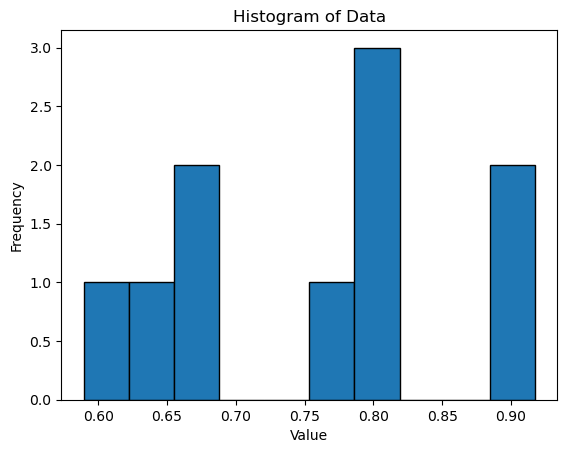

In [3]:
plt.hist(data, bins=10, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Data')
plt.show()

In [8]:
import numpy as np
print(np.array(data).mean())

0.76098
